In [1]:
!pip install opencv-python torch torchvision numpy pandas matplotlib scipy scikit-learn tqdm

In [2]:
!wget -O "/content/Fluo-N2DH-SIM+.zip" \
"https://data.celltrackingchallenge.net/training-datasets/Fluo-N2DH-SIM+.zip"

--2026-06-12 11:05:33--  https://data.celltrackingchallenge.net/training-datasets/Fluo-N2DH-SIM+.zip
Resolving data.celltrackingchallenge.net (data.celltrackingchallenge.net)... 147.251.52.183
Connecting to data.celltrackingchallenge.net (data.celltrackingchallenge.net)|147.251.52.183|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99034393 (94M) [application/zip]
Saving to: ‘/content/Fluo-N2DH-SIM+.zip’

/content/Fluo-N2DH- 100%[===================>]  94.45M  21.0MB/s    in 5.0s    

2026-06-12 11:05:39 (19.0 MB/s) - ‘/content/Fluo-N2DH-SIM+.zip’ saved [99034393/99034393]



In [3]:
# core libraries

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

from tqdm import tqdm

In [4]:
!zip -T "/content/Fluo-N2DH-SIM+.zip"

test of /content/Fluo-N2DH-SIM+.zip OK


In [5]:
import zipfile
with zipfile.ZipFile("/content/Fluo-N2DH-SIM+.zip","r") as z:
    z.extractall("/content/dataset")


!zip -T "/content/Fluo-N2DH-SIM+.zip"

test of /content/Fluo-N2DH-SIM+.zip OK


Frames found: 65


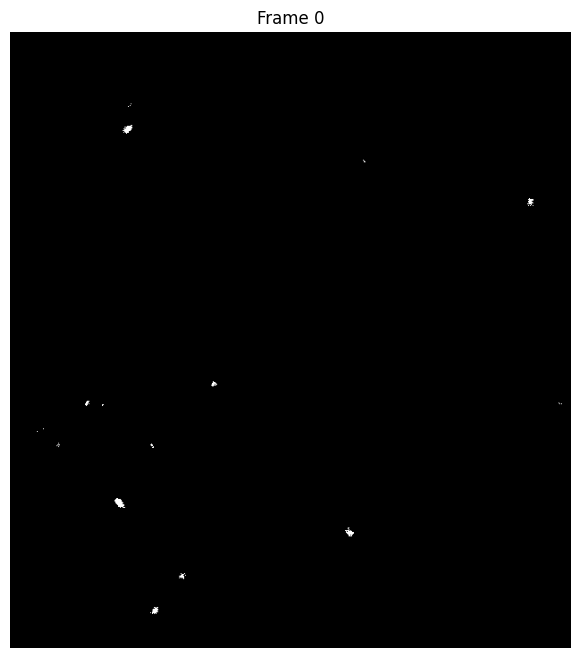

In [6]:
import cv2
import glob
import matplotlib.pyplot as plt

# path to sequence 01
data_path = "/content/dataset/Fluo-N2DH-SIM+/01"

# grab all frames and sort them
frames = sorted(glob.glob(data_path + "/*.tif"))

print(f"Frames found: {len(frames)}")

# quick sanity check
if len(frames) == 0:
    print("No images found. Check dataset path.")
else:
    first_frame = cv2.imread(
        frames[0],
        cv2.IMREAD_GRAYSCALE
    )

    plt.figure(figsize=(8,8))
    plt.imshow(first_frame, cmap="gray")
    plt.title("Frame 0")
    plt.axis("off")
    plt.show()

In [7]:
# reduce small noise and improve contrast

def preprocess(frame):

    blurred = cv2.GaussianBlur(
        frame,
        (5,5),
        0
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(blurred)

    return enhanced

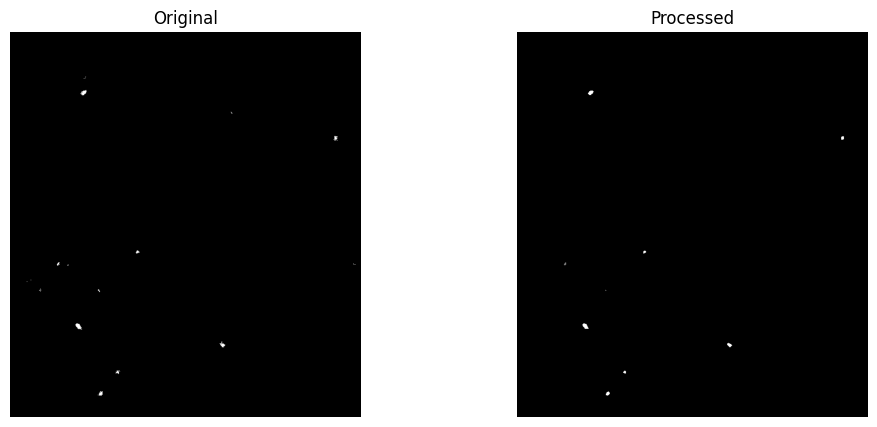

In [8]:
processed = preprocess(first_frame)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(first_frame,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed,cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()

In [9]:
# =====================================================
# CELL DETECTION
# =====================================================

def detect_cells(frame):

    # create binary mask using Otsu threshold
    _, thresh = cv2.threshold(
        frame,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # find connected regions
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    centers = []
    valid_contours = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        # ignore tiny noisy regions
        if area < 5:
            continue

        M = cv2.moments(cnt)

        if M["m00"] == 0:
            continue

        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        centers.append((cx, cy))
        valid_contours.append(cnt)

    return centers, valid_contours, thresh

In [10]:
# run detection on first processed frame

centers, contours, thresh = detect_cells(processed)

print("Detected cells:", len(centers))

Detected cells: 8


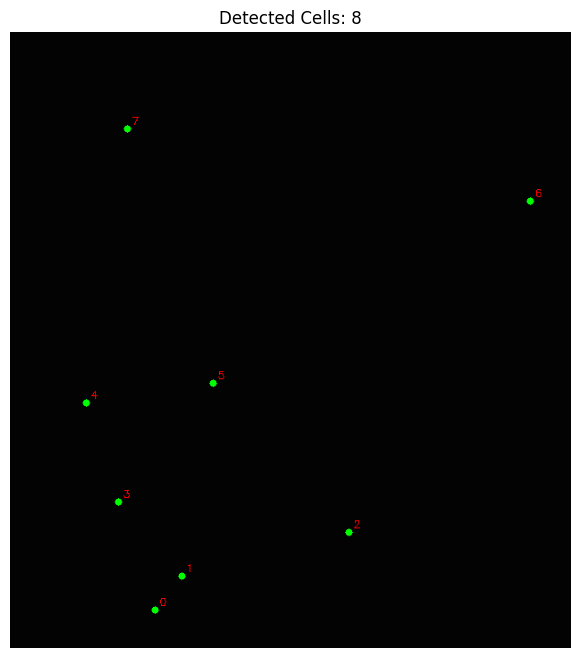

In [11]:
# draw detected centers

display_img = cv2.cvtColor(
    processed,
    cv2.COLOR_GRAY2BGR
)

for idx, (x, y) in enumerate(centers):

    cv2.circle(
        display_img,
        (x, y),
        4,
        (0, 255, 0),
        -1
    )

    cv2.putText(
        display_img,
        str(idx),
        (x + 5, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(8, 8))
plt.imshow(display_img)
plt.title(f"Detected Cells: {len(centers)}")
plt.axis("off")
plt.show()

In [12]:
# check how many detections exist per frame

for i in range(5):

    frame = cv2.imread(
        frames[i],
        cv2.IMREAD_GRAYSCALE
    )

    frame = preprocess(frame)

    detections, _, _ = detect_cells(frame)

    print(
        f"Frame {i}: {len(detections)} detections"
    )

    print(detections[:5])
    print("-" * 40)

Frame 0: 8 detections
[(162, 647), (192, 609), (379, 560), (121, 526), (85, 415)]
----------------------------------------
Frame 1: 7 detections
[(191, 612), (380, 553), (126, 525), (224, 388), (586, 194)]
----------------------------------------
Frame 2: 6 detections
[(189, 619), (376, 554), (115, 525), (583, 199), (134, 111)]
----------------------------------------
Frame 3: 4 detections
[(195, 618), (125, 523), (580, 193), (132, 113)]
----------------------------------------
Frame 4: 6 detections
[(438, 673), (200, 609), (136, 525), (220, 398), (575, 186)]
----------------------------------------


In [13]:
# inspect first frame detections visually

frame = cv2.imread(
    frames[0],
    cv2.IMREAD_GRAYSCALE
)

frame = preprocess(frame)

detections, _, _ = detect_cells(frame)

print("Detections:")
print(detections)

Detections:
[(162, 647), (192, 609), (379, 560), (121, 526), (85, 415), (227, 393), (582, 189), (131, 108)]


SECTION 5 - First Tracker

In [14]:
# distance between two points

import math

def euclidean_distance(p1, p2):

    return math.sqrt(
        (p1[0] - p2[0])**2 +
        (p1[1] - p2[1])**2
    )


# stores trajectories for every cell

tracks = {}

next_track_id = 0

# build trajectories across frames

tracks = {}
next_track_id = 0

max_distance = 30

for frame_idx in range(20):

    frame = cv2.imread(
        frames[frame_idx],
        cv2.IMREAD_GRAYSCALE
    )

    frame = preprocess(frame)

    centers, _, _ = detect_cells(frame)

    # first frame creates initial tracks
    if frame_idx == 0:

        for center in centers:

            tracks[next_track_id] = [center]

            next_track_id += 1

        continue

    # match current detections to existing tracks

    assigned = set()

    for track_id in list(tracks.keys()):

        last_position = tracks[track_id][-1]

        best_distance = float("inf")
        best_center = None

        for center in centers:

            if center in assigned:
                continue

            distance = euclidean_distance(
                last_position,
                center
            )

            if distance < best_distance:

                best_distance = distance
                best_center = center

        # update track if match found
        if best_center is not None and best_distance < max_distance:

            tracks[track_id].append(best_center)

            assigned.add(best_center)

    # create new tracks for unmatched cells

    for center in centers:

        if center not in assigned:

            tracks[next_track_id] = [center]

            next_track_id += 1

In [15]:
print("Total tracks:", len(tracks))

for track_id in list(tracks.keys())[:5]:

    print(
        f"Track {track_id}:",
        len(tracks[track_id]),
        "points"
    )

Total tracks: 55
Track 0: 5 points
Track 1: 9 points
Track 2: 7 points
Track 3: 19 points
Track 4: 1 points


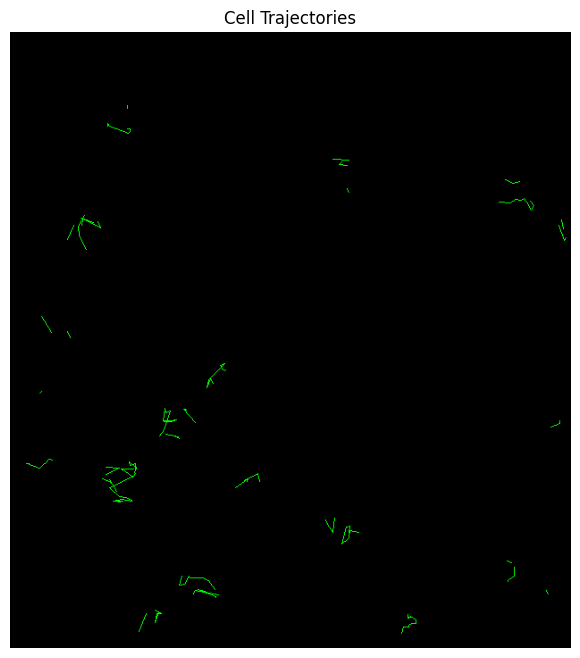

Total tracks: 55


In [16]:
# draw trajectories on first frame

base = cv2.imread(
    frames[0],
    cv2.IMREAD_GRAYSCALE
)

base = cv2.cvtColor(
    base,
    cv2.COLOR_GRAY2BGR
)

for track_id, trajectory in tracks.items():

    if len(trajectory) < 2:
        continue

    for i in range(1, len(trajectory)):

        cv2.line(
            base,
            trajectory[i-1],
            trajectory[i],
            (0,255,0),
            1
        )

plt.figure(figsize=(8,8))
plt.imshow(base)
plt.title("Cell Trajectories")
plt.axis("off")
plt.show()


print("Total tracks:", len(tracks))

In [17]:
track_lengths = []

for track_id, trajectory in tracks.items():
    track_lengths.append(len(trajectory))

print("Number of tracks:", len(track_lengths))
print("Longest track:", max(track_lengths))
print("Shortest track:", min(track_lengths))
print("Average length:", sum(track_lengths)/len(track_lengths))

Number of tracks: 55
Longest track: 19
Shortest track: 1
Average length: 3.672727272727273


**SECTION 6 - Kalman Tracker**

In [18]:
from scipy.optimize import linear_sum_assignment
import numpy as np
import cv2

new algorithm

In [23]:
from scipy.optimize import linear_sum_assignment
import numpy as np

tracks = {}
next_id = 0

max_distance = 60

# initialize using first frame

frame = cv2.imread(
    frames[0],
    cv2.IMREAD_GRAYSCALE
)

frame = preprocess(frame)

detections, _, _ = detect_cells(frame)

for det in detections:

    tracks[next_id] = [det]

    next_id += 1

# process remaining frames

for frame_idx in range(len(frames)):
    frame = cv2.imread(
        frames[frame_idx],
        cv2.IMREAD_GRAYSCALE
    )

    frame = preprocess(frame)

    detections, _, _ = detect_cells(frame)

    if len(detections) == 0:
        continue

    active_ids = list(tracks.keys())

    last_positions = [
        tracks[idx][-1]
        for idx in active_ids
    ]

    cost_matrix = np.zeros(
        (len(last_positions), len(detections))
    )

    for i, pos in enumerate(last_positions):

        for j, det in enumerate(detections):

            cost_matrix[i, j] = np.linalg.norm(
                np.array(pos) - np.array(det)
            )

    rows, cols = linear_sum_assignment(
        cost_matrix
    )

    matched_detections = set()

    for r, c in zip(rows, cols):

        if cost_matrix[r, c] < max_distance:

            track_id = active_ids[r]

            tracks[track_id].append(
                detections[c]
            )

            matched_detections.add(c)

    # create tracks for unmatched detections

    for idx, det in enumerate(detections):

        if idx not in matched_detections:

            tracks[next_id] = [det]

            next_id += 1

In [24]:
track_lengths = [
    len(track)
    for track in tracks.values()
]

print("Total Tracks:", len(track_lengths))
print("Longest Track:", max(track_lengths))
print("Average Length:", np.mean(track_lengths))

Total Tracks: 67
Longest Track: 43
Average Length: 6.313432835820896


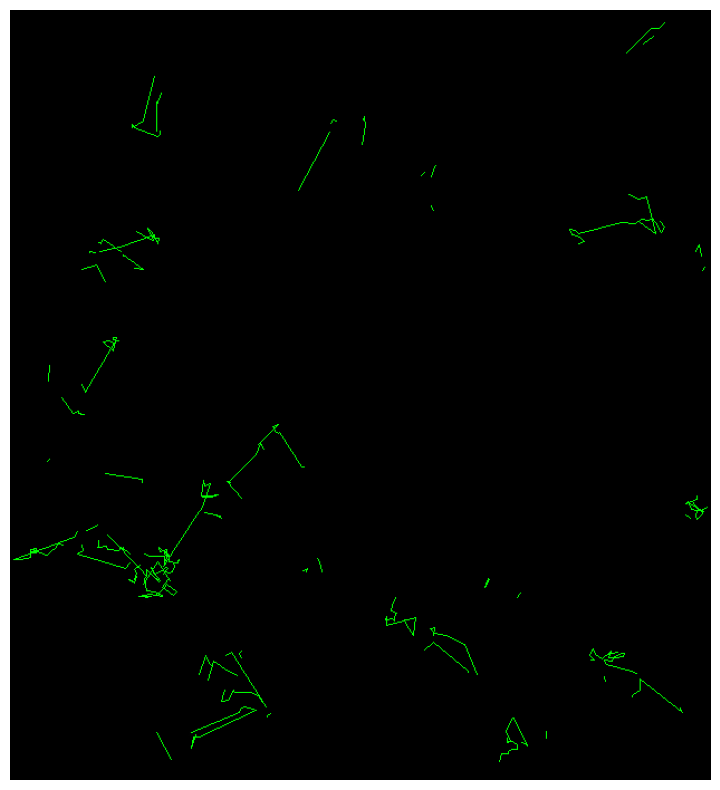

In [25]:
base = cv2.imread(
    frames[0],
    cv2.IMREAD_GRAYSCALE
)

base = cv2.cvtColor(
    base,
    cv2.COLOR_GRAY2BGR
)

for track in tracks.values():

    if len(track) < 2:
        continue

    for i in range(1, len(track)):

        cv2.line(
            base,
            track[i-1],
            track[i],
            (0,255,0),
            1
        )

plt.figure(figsize=(10,10))
plt.imshow(base)
plt.axis("off")
plt.show()

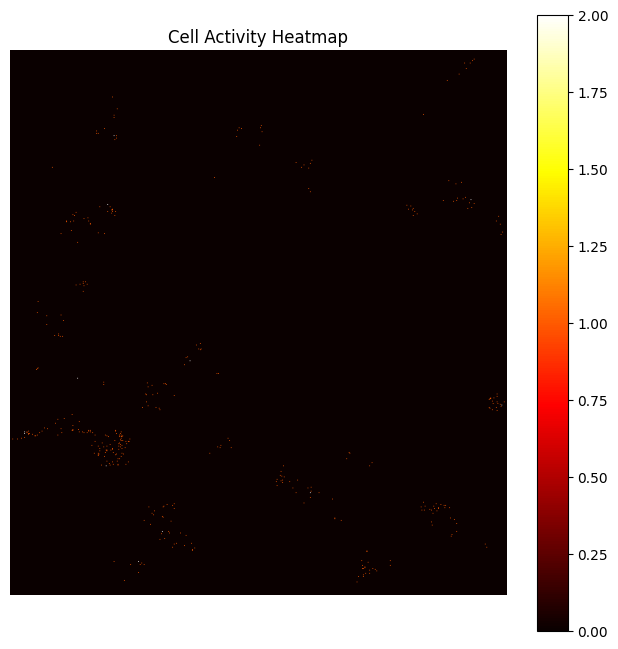

In [26]:
# TRAJECTORY HEATMAP

heatmap = np.zeros(
    first_frame.shape,
    dtype=np.float32
)

for track in tracks.values():

    for x, y in track:

        if (
            0 <= x < heatmap.shape[1]
            and
            0 <= y < heatmap.shape[0]
        ):
          # visualize regions with high cell activity

            heatmap[y, x] += 1

plt.figure(figsize=(8,8))

plt.imshow(
    heatmap,
    cmap="hot"
)

plt.title("Cell Activity Heatmap")
plt.axis("off")

plt.colorbar()

plt.show()

In [27]:
# =====================================================
# TRACK FEATURES
# =====================================================

track_features = []

for track_id, track in tracks.items():

    if len(track) < 3:
        continue

    distances = []

    for i in range(1, len(track)):

        d = np.linalg.norm(
            np.array(track[i])
            -
            np.array(track[i-1])
        )

        distances.append(d)

    total_distance = np.sum(distances)

    avg_speed = np.mean(distances)

    track_features.append({
        "track_id": track_id,
        "length": len(track),
        "total_distance": total_distance,
        "avg_speed": avg_speed
    })

print(
    "Valid Tracks:",
    len(track_features)
)

Valid Tracks: 46


In [28]:
# =====================================================
# BEHAVIOR LABELS
# =====================================================

for item in track_features:

    speed = item["avg_speed"]

    if speed < 2:

        label = "Stationary"

    elif speed < 5:

        label = "Slow"

    elif speed < 10:

        label = "Fast"

    else:

        label = "Highly Migratory"

    item["behavior"] = label

In [29]:
import pandas as pd

df = pd.DataFrame(track_features)

df.head()

,track_id,length,total_distance,avg_speed,behavior
0,0,10,148.902201,16.544689,Highly Migratory
1,1,13,126.748282,10.562357,Highly Migratory
2,2,8,74.992120,10.713160,Highly Migratory
3,3,11,67.173006,6.717301,Fast
4,4,4,36.376639,12.125546,Highly Migratory


In [30]:
print(df["behavior"].value_counts())

behavior
Fast                19
Highly Migratory    18
Slow                 9
Name: count, dtype: int64


In [31]:
# build trajectory dataset

X = []
Y = []

history_length = 5

for track in tracks.values():

    if len(track) <= history_length:
        continue

    for i in range(len(track) - history_length):

        history = track[i:i+history_length]

        target = track[i+history_length]

        X.append(history)
        Y.append(target)

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (191, 5, 2)
Y shape: (191, 2)


In [32]:
# split trajectory samples

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (152, 5, 2)
Test : (39, 5, 2)


In [47]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

/tmp/ipykernel_2162/3247396029.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_2162/3247396029.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
/tmp/ipykernel_2162/3247396029.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_2162/3247396029.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() 

In [45]:
# image dimensions

height = first_frame.shape[0]
width = first_frame.shape[1]

print("Height:", height)
print("Width :", width)

# normalize coordinates

X = X.astype(np.float32)
Y = Y.astype(np.float32)

X[:,:,0] = X[:,:,0] / width
X[:,:,1] = X[:,:,1] / height

Y[:,0] = Y[:,0] / width
Y[:,1] = Y[:,1] / height


print("X range:", X.min(), X.max())
print("Y range:", Y.min(), Y.max())

Height: 690
Width : 628
X range: 7.6067995e-06 0.0015746074
Y range: 7.6067995e-06 0.0015822143


In [63]:
# rebuild dataset from original tracks

X = []
Y = []

history_length = 5

for track in tracks.values():

    if len(track) <= history_length:
        continue

    for i in range(len(track) - history_length):

        history = track[i:i+history_length]
        target = track[i+history_length]

        X.append(history)
        Y.append(target)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print("Before normalization")
print("X range:", X.min(), X.max())
print("Y range:", Y.min(), Y.max())

Before normalization
X range: 3.0 673.0
Y range: 3.0 662.0


In [65]:
model = TrajectoryLSTM()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [67]:
import torch
import torch.nn as nn

class TrajectoryLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            64,
            2
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        last_hidden = hidden[-1]

        prediction = self.fc(last_hidden)

        return prediction


model = TrajectoryLSTM()

print(model)

TrajectoryLSTM(
  (lstm): LSTM(2, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


Loss and Optimizer

In [69]:
height, width = first_frame.shape

X[:,:,0] /= width
X[:,:,1] /= height

Y[:,0] /= width
Y[:,1] /= height

print("After normalization")
print("X range:", X.min(), X.max())
print("Y range:", Y.min(), Y.max())

After normalization
X range: 0.00477707 0.9888535
Y range: 0.00477707 0.9936306


In [70]:
# train for a few epochs

num_epochs = 100

loss_history = []

for epoch in range(num_epochs):

    model.train()

    predictions = model(X_train)

    loss = criterion(
        predictions,
        y_train
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss: {loss.item():.4f}"
        )

Epoch [10/100] Loss: 165085.3906
Epoch [20/100] Loss: 164450.8750
Epoch [30/100] Loss: 163291.7812
Epoch [40/100] Loss: 162257.1875
Epoch [50/100] Loss: 161462.2812
Epoch [60/100] Loss: 160787.7656
Epoch [70/100] Loss: 160169.7656
Epoch [80/100] Loss: 159582.7656
Epoch [90/100] Loss: 159019.9375
Epoch [100/100] Loss: 158475.2969


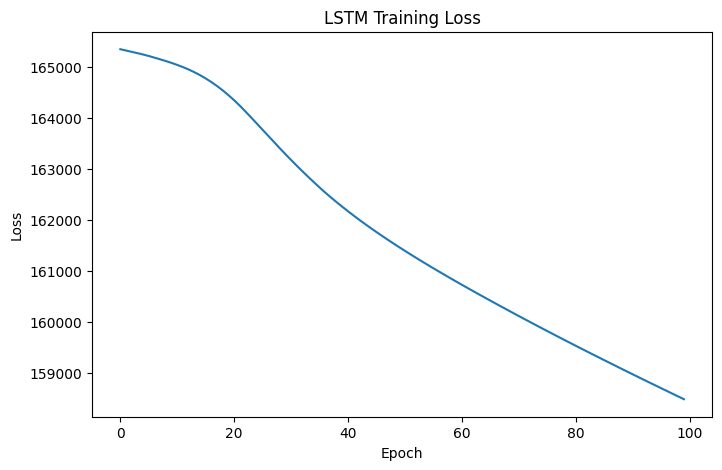

In [71]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training Loss")

plt.show()

In [72]:
model.eval()

with torch.no_grad():

    predictions = model(X_test)

    mse = criterion(
        predictions,
        y_test
    )

print("Test MSE:", mse.item())

Test MSE: 171902.15625


In [84]:
model.eval()

with torch.no_grad():

    predictions = model(X_test)

print("Prediction range:")
print(predictions.min().item(), predictions.max().item())

print("Target range:")
print(y_test.min().item(), y_test.max().item())

Prediction range:
0.032777149230241776 0.9787051677703857
Target range:
0.014331210404634476 0.9888535141944885


In [73]:
print(X.min(), X.max())
print(Y.min(), Y.max())

0.00477707 0.9888535
0.00477707 0.9936306


In [77]:
# create model, loss and optimizer

model = TrajectoryLSTM()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

TrajectoryLSTM(
  (lstm): LSTM(2, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [74]:
# split trajectory samples into train and test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

Train samples: 152
Test samples : 39


In [75]:
# convert numpy arrays into pytorch tensors

import torch

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [76]:
import torch.nn as nn

# predict next cell position from previous positions

class TrajectoryLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        # sequence encoder

        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=128,
            num_layers=2,
            batch_first=True
        )

        # next position predictor

        self.fc = nn.Linear(
            128,
            2
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        # last hidden state contains motion information

        last_hidden = hidden[-1]

        prediction = self.fc(
            last_hidden
        )

        return prediction

In [78]:
# train lstm

num_epochs = 200

loss_history = []

for epoch in range(num_epochs):

    model.train()

    predictions = model(X_train)

    loss = criterion(
        predictions,
        y_train
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 20 == 0:

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Loss: {loss.item():.6f}"
        )

Epoch 20/200 | Loss: 0.048443
Epoch 40/200 | Loss: 0.015466
Epoch 60/200 | Loss: 0.007958
Epoch 80/200 | Loss: 0.001437
Epoch 100/200 | Loss: 0.001051
Epoch 120/200 | Loss: 0.000794
Epoch 140/200 | Loss: 0.000647
Epoch 160/200 | Loss: 0.000538
Epoch 180/200 | Loss: 0.000458
Epoch 200/200 | Loss: 0.000402


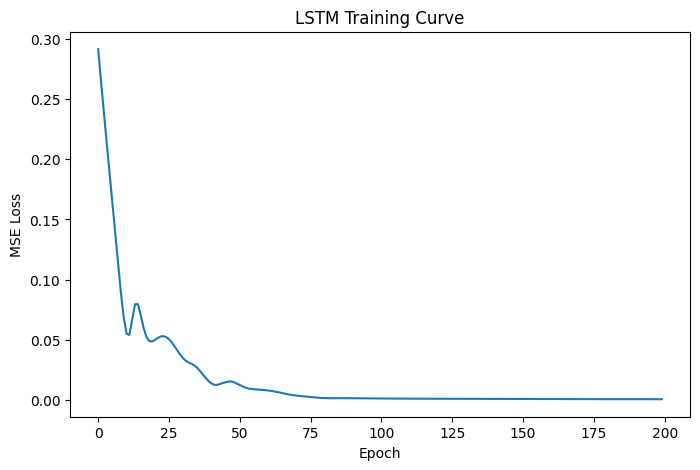

In [79]:
# check if training is converging

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training Curve")

plt.show()

In [80]:
# evaluate on unseen samples

model.eval()

with torch.no_grad():

    predictions = model(X_test)

    mse = criterion(
        predictions,
        y_test
    )

print("Test MSE:", mse.item())

Test MSE: 0.0005407451535575092


In [81]:
# root mean square error

rmse = torch.sqrt(mse)

print("RMSE:", rmse.item())

RMSE: 0.023253927007317543


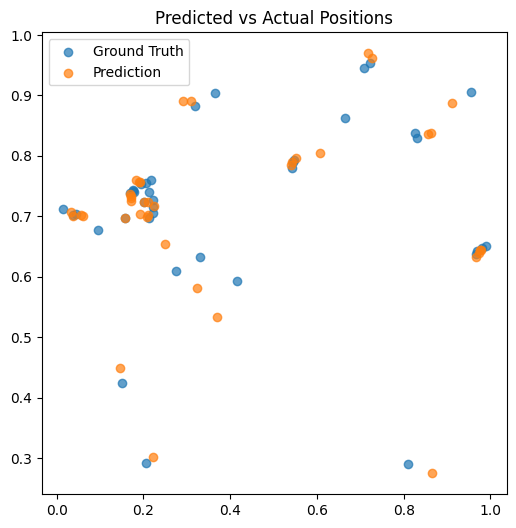

In [82]:
# compare predictions against ground truth

pred_np = predictions.cpu().numpy()

true_np = y_test.cpu().numpy()

plt.figure(figsize=(6,6))

plt.scatter(
    true_np[:,0],
    true_np[:,1],
    label="Ground Truth",
    alpha=0.7
)

plt.scatter(
    pred_np[:,0],
    pred_np[:,1],
    label="Prediction",
    alpha=0.7
)

plt.legend()

plt.title("Predicted vs Actual Positions")

plt.show()

In [85]:
print(X_train.min().item(), X_train.max().item())
print(X_test.min().item(), X_test.max().item())

print(y_train.min().item(), y_train.max().item())
print(y_test.min().item(), y_test.max().item())



print(predictions.min().item(), predictions.max().item())

0.004777070134878159 0.9888535141944885
0.004777070134878159 0.9888535141944885
0.004777070134878159 0.993630588054657
0.014331210404634476 0.9888535141944885
0.032777149230241776 0.9787051677703857


In [86]:
model.eval()

with torch.no_grad():

    train_pred = model(X_train)

    train_mse = criterion(
        train_pred,
        y_train
    )

print("Train MSE:", train_mse.item())

Train MSE: 0.00040026329224929214


In [89]:
# evaluate on test set

model.eval()

with torch.no_grad():

    test_predictions = model(X_test)

    test_mse = criterion(
        test_predictions,
        y_test
    )

    test_rmse = torch.sqrt(
        test_mse
    )

print("Test MSE :", test_mse.item())
print("Test RMSE:", test_rmse.item())

Test MSE : 0.0005407451535575092
Test RMSE: 0.023253927007317543


In [91]:
# convert tensors to numpy

pred_np = test_predictions.cpu().numpy()

true_np = y_test.cpu().numpy()

# average displacement error

ade = np.mean(
    np.linalg.norm(
        pred_np - true_np,
        axis=1
    )
)

# for single-step prediction,
# FDE is same as ADE

fde = np.mean(
    np.linalg.norm(
        pred_np - true_np,
        axis=1
    )
)

print("ADE:", ade)
print("FDE:", fde)

ADE: 0.025515808
FDE: 0.025515808


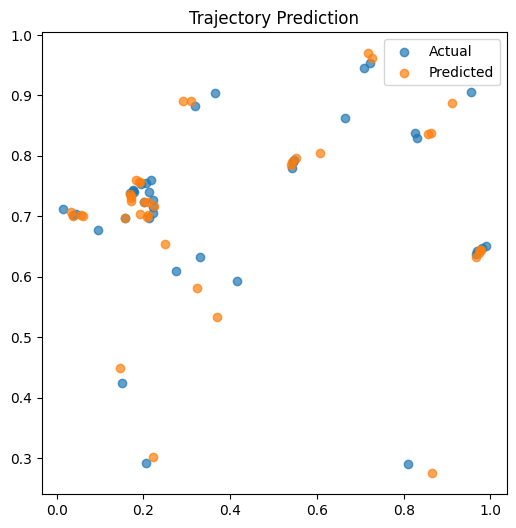

In [92]:
# compare predicted and actual positions

plt.figure(figsize=(6,6))

plt.scatter(
    true_np[:,0],
    true_np[:,1],
    alpha=0.7,
    label="Actual"
)

plt.scatter(
    pred_np[:,0],
    pred_np[:,1],
    alpha=0.7,
    label="Predicted"
)

plt.legend()
plt.title("Trajectory Prediction")
plt.show()

Transformer Model

In [93]:
import torch
import torch.nn as nn


# transformer for trajectory prediction

class TrajectoryTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Linear(
            2,
            64
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Linear(
            64,
            2
        )

    def forward(self, x):

        # project coordinates into embedding space

        x = self.embedding(x)

        # sequence modeling

        x = self.transformer(x)

        # use last timestep

        x = x[:, -1, :]

        prediction = self.fc(x)

        return prediction

In [95]:
# create transformer model

transformer_model = TrajectoryTransformer()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=0.001
)

print(transformer_model)

TrajectoryTransformer(
  (embedding): Linear(in_features=2, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [96]:
# train transformer

num_epochs = 200

transformer_loss = []

for epoch in range(num_epochs):

    transformer_model.train()

    predictions = transformer_model(
        X_train
    )

    loss = criterion(
        predictions,
        y_train
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    transformer_loss.append(
        loss.item()
    )

    if (epoch + 1) % 20 == 0:

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Loss: {loss.item():.6f}"
        )

Epoch 20/200 | Loss: 0.045738
Epoch 40/200 | Loss: 0.026860
Epoch 60/200 | Loss: 0.015940
Epoch 80/200 | Loss: 0.008993
Epoch 100/200 | Loss: 0.010924
Epoch 120/200 | Loss: 0.007695
Epoch 140/200 | Loss: 0.005314
Epoch 160/200 | Loss: 0.005433
Epoch 180/200 | Loss: 0.004958
Epoch 200/200 | Loss: 0.004195


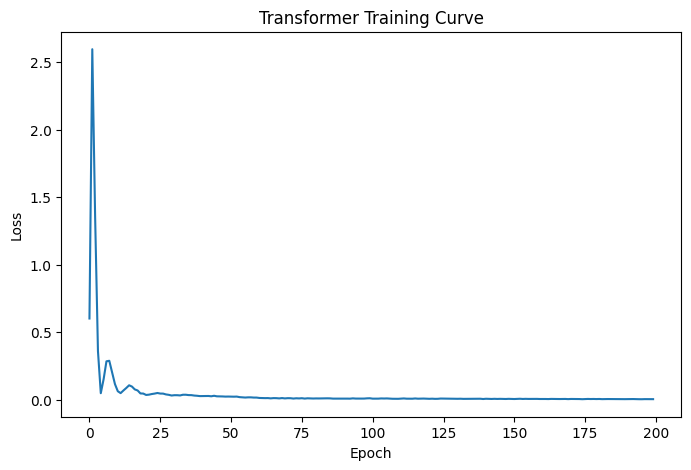

In [97]:
plt.figure(figsize=(8,5))

plt.plot(transformer_loss)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training Curve")

plt.show()

In [98]:
transformer_model.eval()

with torch.no_grad():

    transformer_predictions = transformer_model(
        X_test
    )

    transformer_mse = criterion(
        transformer_predictions,
        y_test
    )

    transformer_rmse = torch.sqrt(
        transformer_mse
    )

print("Transformer MSE :", transformer_mse.item())
print("Transformer RMSE:", transformer_rmse.item())

Transformer MSE : 0.0012484356993809342
Transformer RMSE: 0.03533320873975754


In [99]:
pred_np = transformer_predictions.numpy()

true_np = y_test.numpy()

transformer_ade = np.mean(
    np.linalg.norm(
        pred_np - true_np,
        axis=1
    )
)

transformer_fde = np.mean(
    np.linalg.norm(
        pred_np - true_np,
        axis=1
    )
)

print("Transformer ADE:", transformer_ade)
print("Transformer FDE:", transformer_fde)

Transformer ADE: 0.04729249
Transformer FDE: 0.04729249


In [102]:
comparison = pd.DataFrame({

    "Model": ["LSTM", "Transformer"],

    "ADE": [
        0.0255,
        transformer_ade
    ],

    "FDE": [
        0.0255,
        transformer_fde
    ]
})

comparison

,Model,ADE,FDE
0,LSTM,0.025500,0.025500
1,Transformer,0.047292,0.047292


Predict One Future Point

In [104]:
# take one sample from test set

sample_idx = 0

trajectory = X_test[sample_idx].unsqueeze(0)

model.eval()

with torch.no_grad():

    future_point = model(
        trajectory
    )

past_points = trajectory.squeeze().numpy()

predicted_point = future_point.squeeze().numpy()

actual_point = y_test[sample_idx].numpy()

plot prediction

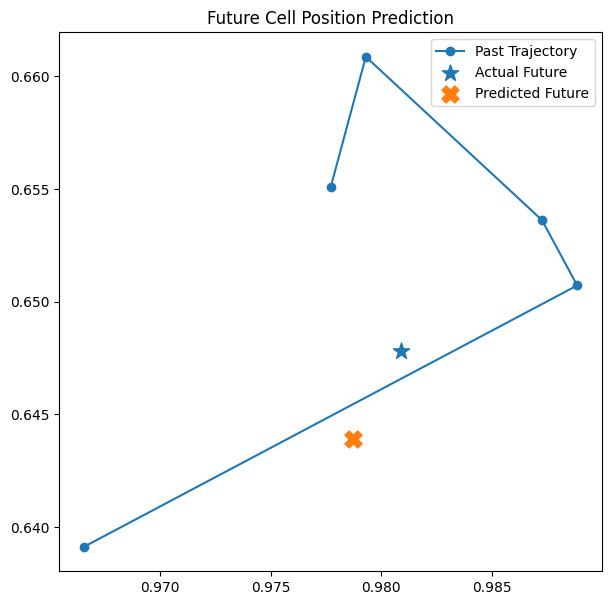

In [105]:
plt.figure(figsize=(7,7))

# past movement

plt.plot(
    past_points[:,0],
    past_points[:,1],
    marker="o",
    label="Past Trajectory"
)

# true future

plt.scatter(
    actual_point[0],
    actual_point[1],
    s=150,
    marker="*",
    label="Actual Future"
)

# predicted future

plt.scatter(
    predicted_point[0],
    predicted_point[1],
    s=150,
    marker="X",
    label="Predicted Future"
)

plt.legend()

plt.title(
    "Future Cell Position Prediction"
)

plt.show()

Recursive Forecast

In [106]:
# generate future trajectory

future_steps = 5

sequence = trajectory.clone()

future_positions = []

model.eval()

with torch.no_grad():

    for _ in range(future_steps):

        next_point = model(sequence)

        future_positions.append(
            next_point.squeeze().numpy()
        )

        next_point_expanded = next_point.unsqueeze(1)

        sequence = torch.cat(
            [
                sequence[:,1:,:],
                next_point_expanded
            ],
            dim=1
        )

plot future path

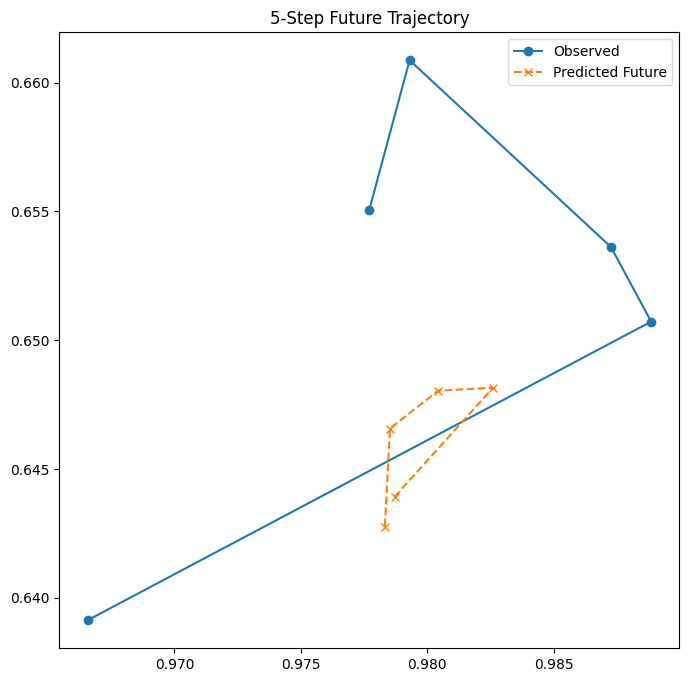

In [107]:
future_positions = np.array(
    future_positions
)

plt.figure(figsize=(8,8))

# observed path

plt.plot(
    past_points[:,0],
    past_points[:,1],
    "o-",
    label="Observed"
)

# predicted future path

plt.plot(
    future_positions[:,0],
    future_positions[:,1],
    "x--",
    label="Predicted Future"
)

plt.legend()

plt.title(
    "5-Step Future Trajectory"
)

plt.show()

In [108]:
results = pd.DataFrame({

    "Model": [
        "LSTM",
        "Transformer"
    ],

    "RMSE": [
        0.02325,
        0.03533
    ],

    "ADE": [
        0.02552,
        0.04729
    ],

    "FDE": [
        0.02552,
        0.04729
    ]
})

results.to_csv(
    "model_comparison.csv",
    index=False
)

results

,Model,RMSE,ADE,FDE
0,LSTM,0.02325,0.02552,0.02552
1,Transformer,0.03533,0.04729,0.04729


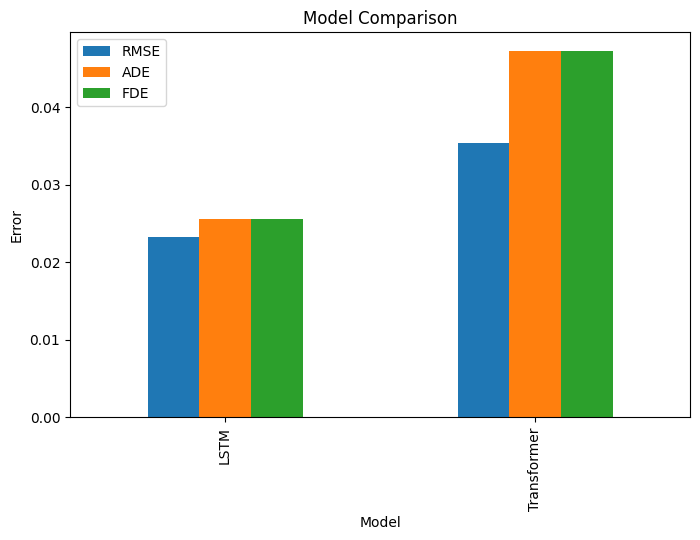

In [111]:
comparison = pd.DataFrame({
    "Model": ["LSTM", "Transformer"],
    "RMSE": [0.02325, 0.03533],
    "ADE": [0.02552, 0.04729],
    "FDE": [0.02552, 0.04729]
})

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Error")
plt.show()

In [112]:
for track_id, track in tracks.items():

    if len(track) < 2:
        continue

    x, y = track[-1]

    cv2.putText(
        base,
        str(track_id),
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        (255,255,255),
        1
    )

In [114]:
# create video showing tracked trajectories

import cv2
import numpy as np

height, width = first_frame.shape

video = cv2.VideoWriter(
    "cell_tracking_demo.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    5,
    (width, height)
)

for frame_idx in range(len(frames)):

    frame = cv2.imread(
        frames[frame_idx],
        cv2.IMREAD_GRAYSCALE
    )

    frame = cv2.cvtColor(
        frame,
        cv2.COLOR_GRAY2BGR
    )

    # draw trajectories

    for track_id, track in tracks.items():

        if len(track) < 2:
            continue

        upto = min(
            frame_idx,
            len(track)-1
        )

        for i in range(1, upto+1):

            cv2.line(
                frame,
                track[i-1],
                track[i],
                (0,255,0),
                1
            )

        x, y = track[upto]

        cv2.circle(
            frame,
            (x,y),
            4,
            (0,0,255),
            -1
        )

    video.write(frame)

video.release()

print("Video saved.")

Video saved.


In [115]:
from google.colab import files

files.download(
    "cell_tracking_demo.mp4"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>